# NumCompute Assignment 2.2 Streaming Iris Demo

This notebook demonstrates the modified NumCompute package on the provided Iris dataset. It uses the custom `IO.load_csv()` pipeline, creates a separate train/test split, splits the training data into stream chunks, trains both a single decision tree and an ensemble incrementally, evaluates final accuracy on the held-out test set, logs chunk-wise metrics, and visualises the results using `numcompute.visualise`.


In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from numcompute.io import IO
from numcompute.pipeline import Pipeline
from numcompute.preprocessing import SimpleImputer, StandardScaler
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.metrics import StreamingClassificationMetric
from numcompute.stats import StreamingStats
from numcompute.visualise import (
    compare_models,
    plot_metric_over_time,
    plot_predictions_vs_ground_truth,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Load the dataset through NumCompute I/O

The assignment requires the demo to load a dataset from a CSV file using the custom I/O pipeline. The Iris CSV contains an `Id` column, four numeric feature columns, and a string class label column.

In [2]:
DATA_PATH = "iris.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "Iris.csv"

iris = IO.load_csv(DATA_PATH, has_headers=True)
print(iris)
print("First 5 rows:")
print(iris.data[:5])


Shape: (150, 6)
Headers: Id: int, SepalLengthCm: float, SepalWidthCm: float, PetalLengthCm: float, PetalWidthCm: float, Species: str
First 5 rows:
[[1.0 5.1 3.5 1.4 0.2 'Iris-setosa']
 [2.0 4.9 3.0 1.4 0.2 'Iris-setosa']
 [3.0 4.7 3.2 1.3 0.2 'Iris-setosa']
 [4.0 4.6 3.1 1.5 0.2 'Iris-setosa']
 [5.0 5.0 3.6 1.4 0.2 'Iris-setosa']]


## 2. Prepare features and labels

The notebook supports both common Iris CSV formats. If the dataset includes an `Id` column, it is removed. The four measurement columns are converted to floats, and the final class column is encoded into integer class IDs.


In [3]:
headers = [col.name for col in iris.cols]
print("Headers:", headers)

# identify the target column and remove non-feature columns such as Id.
lower_headers = [name.lower() for name in headers]

if "species" in lower_headers:
    target_index = lower_headers.index("species")
elif "target" in lower_headers:
    target_index = lower_headers.index("target")
else:
    target_index = len(headers) - 1

feature_indices = [
    idx
    for idx, name in enumerate(lower_headers)
    if idx != target_index and name not in {"id", "index"}
]

feature_names = [headers[idx] for idx in feature_indices]
X = iris.data[:, feature_indices].astype(float)
label_values = iris.data[:, target_index].astype(str)

classes, y = np.unique(label_values, return_inverse=True)

print("Feature columns used:", feature_names)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Class mapping:")
for idx, name in enumerate(classes):
    print(f"  {idx}: {name}")


Headers: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Feature columns used: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Feature matrix shape: (150, 4)
Target shape: (150,)
Class mapping:
  0: Iris-setosa
  1: Iris-versicolor
  2: Iris-virginica


## 3. Create a train/test split

The dataset is shuffled with a fixed random seed. Eighty percent of the rows are used as the training stream, while the remaining twenty percent are kept as a separate test set. The test set is not used during incremental training, so it gives a cleaner final accuracy measurement.


In [4]:
rng = np.random.default_rng(42)
order = rng.permutation(X.shape[0])
X_shuffled = X[order]
y_shuffled = y[order]

test_size = 0.2
split_index = int(X_shuffled.shape[0] * (1 - test_size))

X_train = X_shuffled[:split_index]
y_train = y_shuffled[:split_index]
X_test = X_shuffled[split_index:]
y_test = y_shuffled[split_index:]

print("Training feature shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Test feature shape:", X_test.shape)
print("Test target shape:", y_test.shape)
print("Training class counts:", np.bincount(y_train, minlength=len(classes)))
print("Test class counts:", np.bincount(y_test, minlength=len(classes)))


Training feature shape: (120, 4)
Training target shape: (120,)
Test feature shape: (30, 4)
Test target shape: (30,)
Training class counts: [37 44 39]
Test class counts: [13  6 11]


## 4. Simulate a streaming setting

Real streams arrive in small chunks. In this notebook, only the training rows are split into chunks. The test rows are kept separate until the final evaluation stage.


In [5]:
chunk_size = 15
chunks = []
for start in range(0, X_train.shape[0], chunk_size):
    end = min(start + chunk_size, X_train.shape[0])
    chunks.append((X_train[start:end], y_train[start:end]))

print("Number of training chunks:", len(chunks))
print("Chunk sizes:", [chunk[0].shape[0] for chunk in chunks])
print("First chunk class counts:", np.bincount(chunks[0][1], minlength=len(classes)))


Number of training chunks: 8
Chunk sizes: [15, 15, 15, 15, 15, 15, 15, 15]
First chunk class counts: [4 3 8]


## 5. Track streaming descriptive statistics

`StreamingStats` is updated chunk by chunk using only the training stream. The result is compared with the batch statistics of the training data.


In [6]:
feature_stats = StreamingStats()
for X_chunk, _ in chunks:
    feature_stats.update_stats(X_chunk)

print("Streaming feature means:", feature_stats.mean)
print("Batch training means:   ", np.mean(X_train, axis=0))
print("Streaming feature variance:", feature_stats.variance())
print("Median per feature:", feature_stats.quantile(0.5))


Streaming feature means: [5.859 3.023 3.835 1.214]
Batch training means:    [5.859 3.023 3.835 1.214]
Streaming feature variance: [0.671 0.187 2.937 0.544]
Median per feature: [5.8  3.   4.4  1.35]


## 6. Build two stream-compatible pipelines

The first pipeline uses a single `DecisionTreeClassifier`. The second uses an `EnsembleClassifier`, which trains multiple decision trees with bootstrap samples. Both pipelines share the same preprocessing interface: imputation followed by standard scaling.


In [7]:
single_tree_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=4, min_samples_split=2, random_state=1)),
])

ensemble_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("model", EnsembleClassifier(n_estimators=7, max_depth=4, max_features=2, random_state=1)),
])

single_trainer = StreamTrainer(
    single_tree_pipe,
    metric=StreamingClassificationMetric(metric="accuracy"),
    classes=np.arange(len(classes)),
)
ensemble_trainer = StreamTrainer(
    ensemble_pipe,
    metric=StreamingClassificationMetric(metric="accuracy"),
    classes=np.arange(len(classes)),
)

print("Pipelines ready:")
print("  Single model:", single_tree_pipe.named_steps["model"].__class__.__name__)
print("  Ensemble model:", ensemble_pipe.named_steps["model"].__class__.__name__)

Pipelines ready:
  Single model: DecisionTreeClassifier
  Ensemble model: EnsembleClassifier


## 7. Train incrementally and log real-time metrics

Each model receives the same training chunks through `.partial_fit_score()`. The printed accuracy is based on the current training chunk, while the held-out test accuracy is calculated later on data the model has not trained on.


In [8]:
single_times = []
ensemble_times = []
latest_y_true = None
latest_single_pred = None
latest_ensemble_pred = None

print("Streaming progress")
print("chunk | tree_acc | forest_acc | tree_cum | forest_cum | tree_ms | forest_ms")
print("-" * 78)

for idx, (X_chunk, y_chunk) in enumerate(chunks, start=1):
    start = time.perf_counter()
    tree_acc = single_trainer.partial_fit_score(X_chunk, y_chunk)
    single_times.append((time.perf_counter() - start) * 1000)

    start = time.perf_counter()
    forest_acc = ensemble_trainer.partial_fit_score(X_chunk, y_chunk)
    ensemble_times.append((time.perf_counter() - start) * 1000)

    latest_y_true = y_chunk
    latest_single_pred = single_tree_pipe.predict(X_chunk)
    latest_ensemble_pred = ensemble_pipe.predict(X_chunk)

    print(
        f"{idx:>5} | {tree_acc:>8.3f} | {forest_acc:>10.3f} | "
        f"{single_trainer.logs['cumulative_accuracy'][-1]:>8.3f} | "
        f"{ensemble_trainer.logs['cumulative_accuracy'][-1]:>10.3f} | "
        f"{single_times[-1]:>7.2f} | {ensemble_times[-1]:>9.2f}"
    )

Streaming progress
chunk | tree_acc | forest_acc | tree_cum | forest_cum | tree_ms | forest_ms
------------------------------------------------------------------------------
    1 |    1.000 |      1.000 |    1.000 |      1.000 |    7.68 |     14.02
    2 |    1.000 |      1.000 |    1.000 |      1.000 |    7.61 |     22.49
    3 |    1.000 |      1.000 |    1.000 |      1.000 |   15.00 |     48.62
    4 |    1.000 |      1.000 |    1.000 |      1.000 |   25.36 |     57.95
    5 |    1.000 |      1.000 |    1.000 |      1.000 |   35.99 |     71.88
    6 |    1.000 |      1.000 |    1.000 |      1.000 |   44.63 |     88.22
    7 |    1.000 |      0.933 |    1.000 |      0.990 |   40.21 |     95.05
    8 |    1.000 |      1.000 |    1.000 |      0.992 |   54.96 |    119.80


## 8. Evaluate on the held-out test set

After all training chunks have been processed, both models are evaluated on the separate test set. This gives a final accuracy value on unseen data.


In [9]:
test_single_pred = single_tree_pipe.predict(X_test)
test_ensemble_pred = ensemble_pipe.predict(X_test)

single_test_accuracy = np.mean(test_single_pred == y_test)
ensemble_test_accuracy = np.mean(test_ensemble_pred == y_test)

print("Held-out test accuracy")
print(f"  Single decision tree: {single_test_accuracy:.3f}")
print(f"  Ensemble:             {ensemble_test_accuracy:.3f}")
print()
print("Test class counts:", np.bincount(y_test, minlength=len(classes)))
print("Single tree predicted counts:", np.bincount(test_single_pred, minlength=len(classes)))
print("Ensemble predicted counts:   ", np.bincount(test_ensemble_pred, minlength=len(classes)))


Held-out test accuracy
  Single decision tree: 0.933
  Ensemble:             0.967

Test class counts: [13  6 11]
Single tree predicted counts: [13  6 11]
Ensemble predicted counts:    [13  5 12]


## 8. Visualise training-stream metric trends using `visualise.py`

The built-in visualisation module is used for individual metric trends and model comparison across the training stream.


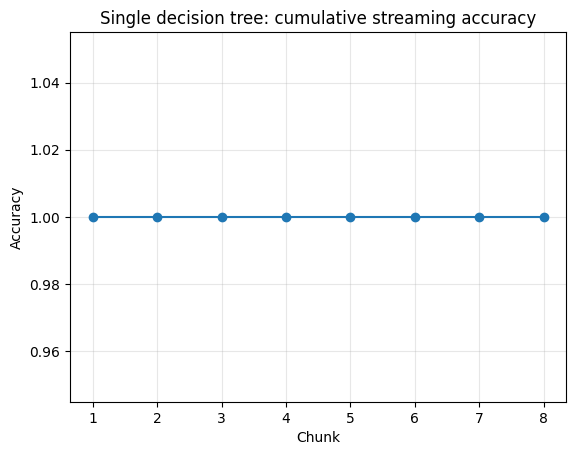

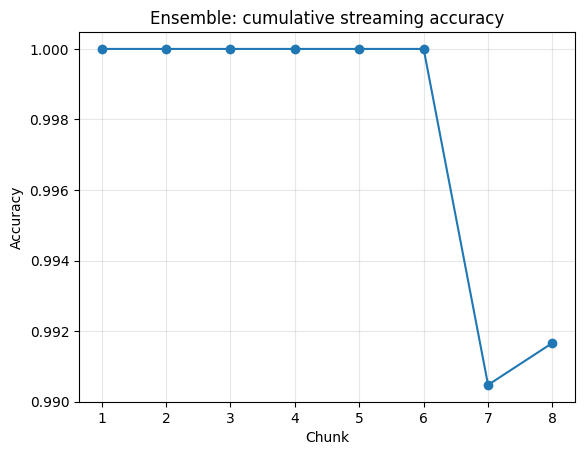

In [10]:
fig1 = plot_metric_over_time(
    single_trainer.logs["cumulative_accuracy"],
    title="Single decision tree: cumulative streaming accuracy",
    ylabel="Accuracy",
    show=False,
)
plt.show()

fig2 = plot_metric_over_time(
    ensemble_trainer.logs["cumulative_accuracy"],
    title="Ensemble: cumulative streaming accuracy",
    ylabel="Accuracy",
    show=False,
)
plt.show()

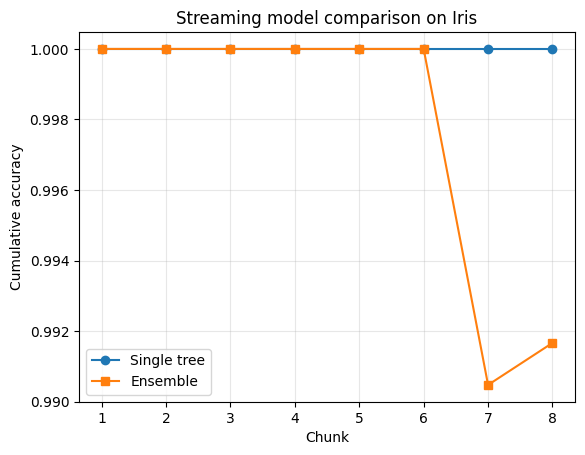

In [11]:
fig3 = compare_models(
    single_trainer.logs["cumulative_accuracy"],
    ensemble_trainer.logs["cumulative_accuracy"],
    labels=("Single tree", "Ensemble"),
    title="Streaming model comparison on Iris",
    ylabel="Cumulative accuracy",
    show=False,
)
plt.show()

## 10. Visualise test predictions against ground truth

This cell compares the held-out test labels with the ensemble predictions after all streaming training chunks have been processed.


Test true labels:       [2 0 0 2 2 1 2 1 0 0 1 0 1 0 0 2 2 0 2 0 0 1 0 2 2 0 2 0 1 2]
Test ensemble labels:   [2 0 0 2 2 1 2 1 0 0 1 0 2 0 0 2 2 0 2 0 0 1 0 2 2 0 2 0 1 2]
Class names: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


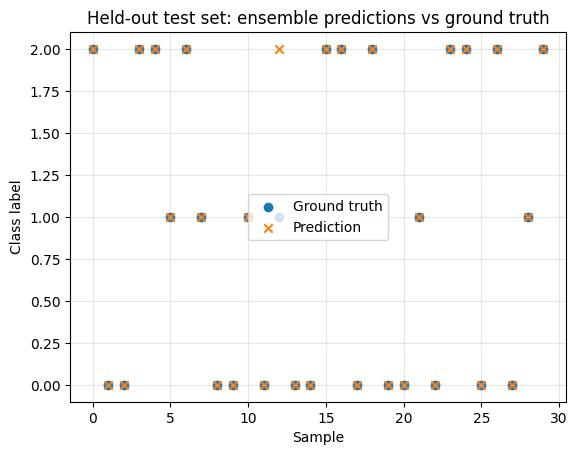

In [12]:
print("Test true labels:      ", y_test)
print("Test ensemble labels:  ", test_ensemble_pred)
print("Class names:", classes)

fig4 = plot_predictions_vs_ground_truth(
    y_test,
    test_ensemble_pred,
    title="Held-out test set: ensemble predictions vs ground truth",
    show=False,
)
plt.show()


## 11. Lightweight benchmark evidence

This quick table compares the average update time of the single tree and the ensemble during the streaming run. The ensemble is expected to be slower because it trains multiple trees, but it provides model averaging through majority vote.


Average update + score time
  Single decision tree: 28.93 ms per chunk
  Ensemble:             64.75 ms per chunk
  Relative cost:        2.24x


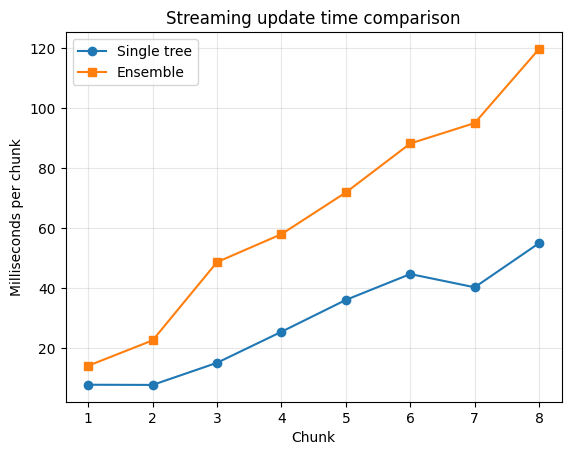

In [13]:
print("Average update + score time")
print(f"  Single decision tree: {np.mean(single_times):.2f} ms per chunk")
print(f"  Ensemble:             {np.mean(ensemble_times):.2f} ms per chunk")
print(f"  Relative cost:        {np.mean(ensemble_times) / np.mean(single_times):.2f}x")

fig5 = compare_models(
    single_times,
    ensemble_times,
    labels=("Single tree", "Ensemble"),
    title="Streaming update time comparison",
    ylabel="Milliseconds per chunk",
    show=False,
)
plt.show()

## 13. Running tests

The command below is commented out so the notebook does not unexpectedly run a full test suite. Uncomment it when running from the project root if `pytest` is installed.

In [14]:
!python -m pytest "$PROJECT_ROOT"/"tests"/*

============================= test session starts ==============================
platform linux -- Python 3.14.3, pytest-9.0.3, pluggy-1.6.0
rootdir: /mnt/d/Adelaide University/Semester 1/Programming for AI 1/Assignments/NumCompute
configfile: pyproject.toml
collected 230 items                                                            

../tests/test_benchmarking.py ........                                   [  3%]
../tests/test_edge_cases.py .......                                      [  6%]
../tests/test_ensemble.py ........                                       [ 10%]
../tests/test_io.py ........                                             [ 13%]
../tests/test_metrics.py ...............                                 [ 20%]
../tests/test_optim.py ..............                                    [ 26%]
../tests/test_pipeline.py ......                                         [ 28%]
../tests/test_pipeline_streaming.py ...                                  [ 30%]
../tests/test_prepro